## 0. Environment Setup

In [1]:
import warnings
from dataclasses import dataclass, field
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "neutral": "#B0BEC5",
    "accent": "#ab47bc",
}

# —— V3 Safety Constants (must match backend/config/constants.py) —————————————
PROFIT_TARGET = 0.20  # Auto profit-taking threshold
MAX_DRAWDOWN_LIMIT = 0.10  # Position drawdown circuit breaker
DAILY_LOSS_LIMIT = 0.03  # Daily loss circuit breaker

print(
    f"Safety constants: profit_take={PROFIT_TARGET:.0%} | "
    f"max_dd={MAX_DRAWDOWN_LIMIT:.0%} | daily_loss={DAILY_LOSS_LIMIT:.0%}"
)

Safety constants: profit_take=20% | max_dd=10% | daily_loss=3%


## 1. Event-Driven Backtesting Engine

In [2]:
@dataclass
class Trade:
    """Records a completed round-trip trade."""

    ticker: str
    entry_dt: pd.Timestamp
    exit_dt: pd.Timestamp
    entry_px: float
    exit_px: float
    direction: int  # +1 long, -1 short
    shares: float
    pnl: float = field(init=False)
    pnl_pct: float = field(init=False)
    exit_reason: str = "signal"

    def __post_init__(self) -> None:
        self.pnl = (
            (self.exit_px - self.entry_px) * self.direction * self.shares
        )
        self.pnl_pct = (self.exit_px / self.entry_px - 1) * self.direction


@dataclass
class BacktestConfig:
    """
    Backtest configuration — mirrors SimulationConfig in backend/simulation.
    """

    initial_capital: float = 100_000.0
    position_size: float = 0.10  # fraction of equity per trade
    commission_pct: float = 0.01  # 0.10% per trade (round-trip)
    slippage_pct: float = 0.0005  # 0.05% market impact
    profit_target: float = PROFIT_TARGET
    max_drawdown: float = MAX_DRAWDOWN_LIMIT
    daily_loss_limit: float = DAILY_LOSS_LIMIT
    allow_short: bool = False


class EventDrivenBacktester:
    """
    Minimal event-driven backtester that enforces V3 safety rules.
    The Safety Arbitrator hard rules are enforced here exactly as
    described in backend/execution/safety/arbitrator.py.
    """

    def __init__(self, config: BacktestConfig) -> None:
        self.cfg = config
        self.equity = config.initial_capital
        self.cash = config.initial_capital
        self.positions: dict[str, dict] = {}
        self.trades: list[Trade] = []
        self.equity_curve: list[float] = []
        self.timestamps: list = []
        self._day_start_equity: float = config.initial_capital
        self._current_date = None
        self._kill_switch = False
        self._safety_events: list[str] = []

    # —— Internal helpers —————————————————————————————————————————————————————
    def _apply_slippage(self, price: float, direction: int) -> float:
        return price * (1 + direction * self.cfg.slippage_pct)

    def _apply_commission(self, notional: float) -> float:
        return notional * self.cfg.commission_pct

    def _check_daily_reset(self, dt: pd.Timestamp) -> None:
        if self._current_date != dt.date():
            self._daily_start_equity = self.equity
            self._current_date = dt.date()

    def _daily_loss_hit(self) -> bool:
        """Daily loss circuit breaker — §8 Hard Constraint Veto."""
        daily_loss = (
            self.equity - self._daily_start_equity
        ) / self._daily_start_equity
        return daily_loss < -self.cfg.daily_loss_limit

    def _max_drawdown_hit(self, ticker: str) -> bool:
        """Per-position drawdown circuit breaker."""
        pos = self.positions.get(ticker)
        if pos is None:
            return False
        drawdown = (pos["current_px"] / pos["entry_px"] - 1) * pos["direction"]
        return drawdown < -self.cfg.max_drawdown

    def _profit_target_hit(self, ticker: str) -> bool:
        """Profit-taking rule: liquidate at +20% gain (§1 philosophy)."""
        pos = self.positions.get(ticker)
        if pos is None:
            return False
        gain = (pos["current_px"] / pos["entry_px"] - 1) * pos["direction"]
        return gain >= self.cfg.profit_target

    # ── Public API ───────────────────────────────────────────────────────────
    def enter(
        self, ticker: str, price: float, direction: int, dt: pd.Timestamp
    ) -> bool:
        """
        Enter a position.  Returns False if safety rules blocked the entry.
        """
        if self._kill_switch:
            return False
        if self._daily_loss_hit():
            self._safety_events.append(
                f"{dt} — Daily loss limit hit, blocking entry"
            )
            return False
        if ticker in self.positions:
            return False  # Already in this position

        fill_price = self._apply_slippage(price, direction)
        shares = (self.equity * self.cfg.position_size) / fill_price
        notional = fill_price * shares
        commission = self._apply_commission(notional)

        if notional + commission > self.cash:
            return False  # Insufficient capital

        self.cash -= notional + commission
        self.positions[ticker] = {
            "entry_px": fill_price,
            "current_px": fill_price,
            "shares": shares,
            "direction": direction,
            "entry_dt": dt,
        }
        return True

    def exit(
        self,
        ticker: str,
        price: float,
        dt: pd.Timestamp,
        reason: str = "signal",
    ) -> Trade | None:
        """Exit an open position and record the trade."""
        pos = self.positions.pop(ticker, None)
        if pos is None:
            return None

        fill_price = self._apply_slippage(price, -pos["direction"])
        commission = self._apply_commission(fill_price * pos["shares"])
        proceeds = fill_price * pos["shares"] - commission
        self.cash += proceeds

        trade = Trade(
            ticker=ticker,
            entry_dt=pos["entry_dt"],
            exit_dt=dt,
            entry_px=pos["entry_px"],
            exit_px=fill_price,
            direction=pos["direction"],
            shares=pos["shares"],
            exit_reason=reason,
        )
        self.trades.append(trade)
        return trade

    def tick(self, ticker: str, price: float, dt: pd.Timestamp) -> list[str]:
        """
        Update mark-to-market and enforce Safety Arbitrator hard rules.
        Returns list of triggered safety events.
        """
        self._check_daily_reset(dt)
        events: list[str] = []

        if ticker in self.positions:
            self.positions[ticker]["current_px"] = price

            # Profit-taking: auto-liquidate at +20%
            if self._profit_target_hit(ticker):
                self.exit(ticker, price, dt, reason="profit_take")
                msg = f"{dt} — {ticker}: PROFIT TAKE at {price:.2f}"
                events.append(msg)
                self._safety_events.append(msg)

            # Drawdown circuit breaker
            elif self._max_drawdown_hit(ticker):
                self.exit(ticker, price, dt, reason="drawdown_limit")
                msg = f"{dt} — {ticker}: DRAWDOWN LIMIT hit at {price:.2f}"
                events.append(msg)
                self._safety_events.append(msg)

        # Daily loss check
        if self._daily_loss_hit() and ticker in self.positions:
            self.exit(ticker, price, dt, reason="daily_loss_limit")
            msg = f"{dt} — Daily loss limit: closing {ticker}"
            events.append(msg)
            self._safety_events.append(msg)

        # Recompute equity
        mark_to_market = sum(
            p["current_px"] * p["shares"] * p["direction"]
            for p in self.positions.values()
        )
        self.equity = self.cash + mark_to_market
        self.equity_curve.append(self.equity)
        self.timestamps.append(dt)
        return events

    def results(self) -> dict:
        """Compute strategy performance metrics."""
        if not self.trades:
            return {"error": "No trades executed"}

        eq = pd.Series(self.equity_curve, index=self.timestamps)
        ret = eq.pct_change().dropna()

        wins = [t for t in self.trades if t.pnl > 0]
        losses = [t for t in self.trades if t.pnl <= 0]
        total_pnl = sum(t.pnl for t in self.trades)

        # Sharpe Ratio (annualised, daily frequency assumed)
        sharpe = (
            ret.mean() / ret.std() * np.sqrt(252) if ret.std() > 0 else 0.0
        )

        # Sortino Ratio (downside deviation only)
        downside = ret[ret < 0].std()
        sortino = ret.mean() / downside * np.sqrt(252) if downside > 0 else 0.0

        # Max Drawdown
        roll_max = eq.cummax()
        dd_series = (eq - roll_max) / roll_max
        max_dd = dd_series.min()

        return {
            "total_return": (eq.iloc[-1] / self.cfg.initial_capital - 1),
            "total_pnl": total_pnl,
            "sharpe_ratio": sharpe,
            "sortino_ratio": sortino,
            "max_drawdown": max_dd,
            "n_trades": len(self.trades),
            "win_rate": len(wins) / len(self.trades),
            "avg_win_pct": np.mean([t.pnl_pct for t in wins]) if wins else 0,
            "avg_loss_pct": np.mean([t.pnl_pct for t in losses])
            if losses
            else 0,
            "profit_takes": sum(
                1 for t in self.trades if t.exit_reason == "profit_take"
            ),
            "drawdown_exits": sum(
                1 for t in self.trades if t.exit_reason == "drawdown_limit"
            ),
            "daily_loss_exits": sum(
                1 for t in self.trades if t.exit_reason == "daily_loss_limit"
            ),
            "safety_events": len(self._safety_events),
        }


print("EventDrivenBacktester defined ✅")

EventDrivenBacktester defined ✅


## 2. Strategy Implementations

In [3]:
# ── Moving Average Crossover (Simple V2 baseline) ───────────────────────────
def ma_crossover_strategy(
    df: pd.DataFrame, fast: int = 20, slow: int = 50
) -> pd.Series:
    """Returns +1 (long), -1 (short), 0 (flat) for each bar."""
    ma_fast = df["Close"].rolling(fast).mean()
    ma_slow = df["Close"].rolling(slow).mean()
    signal = pd.Series(0, index=df.index)
    signal[ma_fast > ma_slow] = 1
    signal[ma_fast < ma_slow] = -1
    return signal.shift(1).fillna(0)  # shift to avoid look-ahead


# ── RSI Mean Reversion ────────────────────────────────────────────────────
def rsi_strategy(
    df: pd.DataFrame,
    period: int = 14,
    oversold: float = 30,
    overbought: float = 70,
) -> pd.Series:
    """Buy oversold, sell overbought."""
    delta = df["Close"].diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / period, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / period, adjust=False).mean()
    rsi = 100 - 100 / (1 + gain / loss.replace(0, np.nan))
    signal = pd.Series(0, index=df.index)
    signal[rsi < oversold] = 1
    signal[rsi > overbought] = -1
    return signal.shift(1).fillna(0)


print("Strategy functions defined ✅")

Strategy functions defined ✅


## 3. Run Backtest on Historical Data

In [4]:
# Download data for backtesting period
END = datetime.today()
START = END - timedelta(days=365 * 5)
TICKER = "SPY"

raw = yf.download(
    TICKER,
    start=START,
    end=END,
    interval="1d",
    progress=False,
    auto_adjust=True,
    multi_level_index=False,
)
raw.index = pd.to_datetime(raw.index)

signals_ma = ma_crossover_strategy(raw)
signals_rsi = rsi_strategy(raw)

# Run both strategies
strategies = {
    "MA Crossover (20/50)": signals_ma,
    "RSI Mean Reversion": signals_rsi,
}

all_results = {}
all_equity = {}

for name, signals in strategies.items():
    cfg = BacktestConfig(initial_capital=100_000.0)
    bt = EventDrivenBacktester(cfg)

    for dt, row in raw.iterrows():
        price = float(row["Close"])
        signal = int(signals.loc[dt])

        # Safety arbitrator tick
        bt.tick(TICKER, price, dt)

        # Signal execution
        if signal == 1 and TICKER not in bt.positions:
            bt.enter(TICKER, price, direction=1, dt=dt)
        elif signal != 1 and TICKER in bt.positions:
            bt.exit(TICKER, price, dt=dt, reason="signal")

    # Close any open position at end
    if TICKER in bt.positions:
        bt.exit(
            TICKER,
            float(raw["Close"].iloc[-1]),
            dt=raw.index[-1],
            reason="end_of_backtest",
        )

    res = bt.results()
    all_results[name] = res
    all_equity[name] = pd.Series(bt.equity_curve, index=bt.timestamps)
    print(f"\n[{name}]")
    for k, v in res.items():
        if k != "error":
            if isinstance(v, float):
                print(f"  {k:<22}: {v:+.4f}")
            else:
                print(f"  {k:<22}: {v}")

# Buy-and-hold benchmark
bh_equity = (raw["Close"] / raw["Close"].iloc[0]) * 100_000.0
all_equity["Buy & Hold"] = bh_equity


[MA Crossover (20/50)]
  total_return          : -0.0060
  total_pnl             : +1776.4477
  sharpe_ratio          : -0.0980
  sortino_ratio         : -0.1083
  max_drawdown          : -0.0428
  n_trades              : 12
  win_rate              : +0.5000
  avg_win_pct           : +0.0835
  avg_loss_pct          : -0.0526
  profit_takes          : 0
  drawdown_exits        : 0
  daily_loss_exits      : 0
  safety_events         : 0

[RSI Mean Reversion]
  total_return          : -0.0079
  total_pnl             : +815.0565
  sharpe_ratio          : -0.2598
  sortino_ratio         : -0.0934
  max_drawdown          : -0.0135
  n_trades              : 8
  win_rate              : +0.6250
  avg_win_pct           : +0.0206
  avg_loss_pct          : -0.0070
  profit_takes          : 0
  drawdown_exits        : 0
  daily_loss_exits      : 0
  safety_events         : 0


## 4. Performance Visualisation

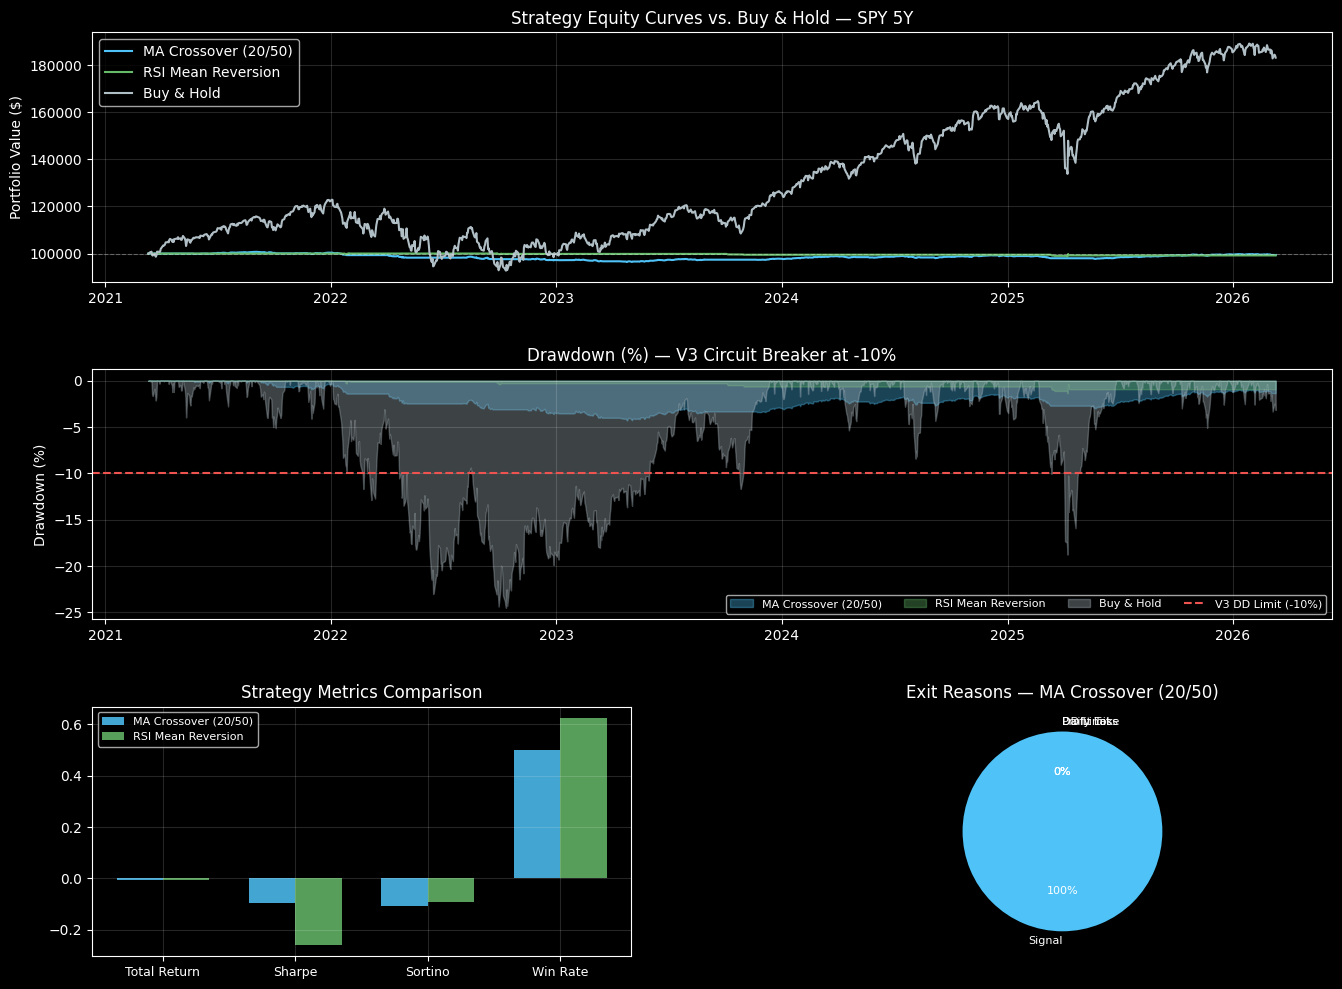

Saved → 04_backtest_results.png


In [5]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

# ── Equity Curves ──────────────────────────────────────────────────────────
ax_eq = fig.add_subplot(gs[0, :])
strategy_colors = [COLORS["primary"], COLORS["success"], COLORS["neutral"]]
for (name, eq), color in zip(
    all_equity.items(), strategy_colors, strict=False
):
    ax_eq.plot(eq.index, eq, label=name, linewidth=1.5, color=color)
ax_eq.axhline(100_000, color="white", linestyle="--", alpha=0.3, linewidth=0.8)
ax_eq.set_title("Strategy Equity Curves vs. Buy & Hold — SPY 5Y")
ax_eq.set_ylabel("Portfolio Value ($)")
ax_eq.legend()
ax_eq.grid(alpha=0.15)

# ── Drawdown ───────────────────────────────────────────────────────────────
ax_dd = fig.add_subplot(gs[1, :])
for (name, eq), color in zip(
    all_equity.items(), strategy_colors, strict=False
):
    roll_max = eq.cummax()
    dd = (eq - roll_max) / roll_max * 100
    ax_dd.fill_between(eq.index, dd, 0, alpha=0.35, color=color, label=name)
ax_dd.axhline(
    -MAX_DRAWDOWN_LIMIT * 100,
    color=COLORS["danger"],
    linestyle="--",
    linewidth=1.5,
    label="V3 DD Limit (-10%)",
)
ax_dd.set_title("Drawdown (%) — V3 Circuit Breaker at -10%")
ax_dd.set_ylabel("Drawdown (%)")
ax_dd.legend(ncol=4, fontsize=8)
ax_dd.grid(alpha=0.15)

# ── Metrics Bar Chart ─────────────────────────────────────────────────────
metric_keys = ["total_return", "sharpe_ratio", "sortino_ratio", "win_rate"]
metric_labels = ["Total Return", "Sharpe", "Sortino", "Win Rate"]
ax_bar = fig.add_subplot(gs[2, 0])
n_strategies = len(all_results)
x = np.arange(len(metric_keys))
width = 0.35

for i, (name, res) in enumerate(all_results.items()):
    vals = [res.get(k, 0) for k in metric_keys]
    bars = ax_bar.bar(
        x + i * width,
        vals,
        width,
        label=name,
        alpha=0.85,
        color=[COLORS["primary"], COLORS["success"]][i],
    )
ax_bar.set_xticks(x + width / 2)
ax_bar.set_xticklabels(metric_labels, fontsize=9)
ax_bar.set_title("Strategy Metrics Comparison")
ax_bar.legend(fontsize=8)
ax_bar.grid(alpha=0.15)

# ── Safety Events Pie Chart ───────────────────────────────────────────────
ax_pie = fig.add_subplot(gs[2, 1])
for name, res in all_results.items():
    pie_data = [
        res.get("profit_takes", 0),
        res.get("drawdown_exits", 0),
        res.get("daily_loss_exits", 0),
        res.get("n_trades", 0)
        - res.get("profit_takes", 0)
        - res.get("drawdown_exits", 0)
        - res.get("daily_loss_exits", 0),
    ]
    labels = ["Profit Take", "DD Limit", "Daily Loss", "Signal"]
    colors_pie = [
        COLORS["success"],
        COLORS["danger"],
        COLORS["warning"],
        COLORS["primary"],
    ]
    wedges, texts, autotexts = ax_pie.pie(
        pie_data,
        labels=labels,
        colors=colors_pie,
        autopct="%1.0f%%",
        startangle=90,
        textprops={"fontsize": 8},
    )
    ax_pie.set_title(f"Exit Reasons — {name}")
    break  # Show first strategy only

plt.savefig("04/04_backtest_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 04_backtest_results.png")

## 5. 2020 COVID Crash Stress Test

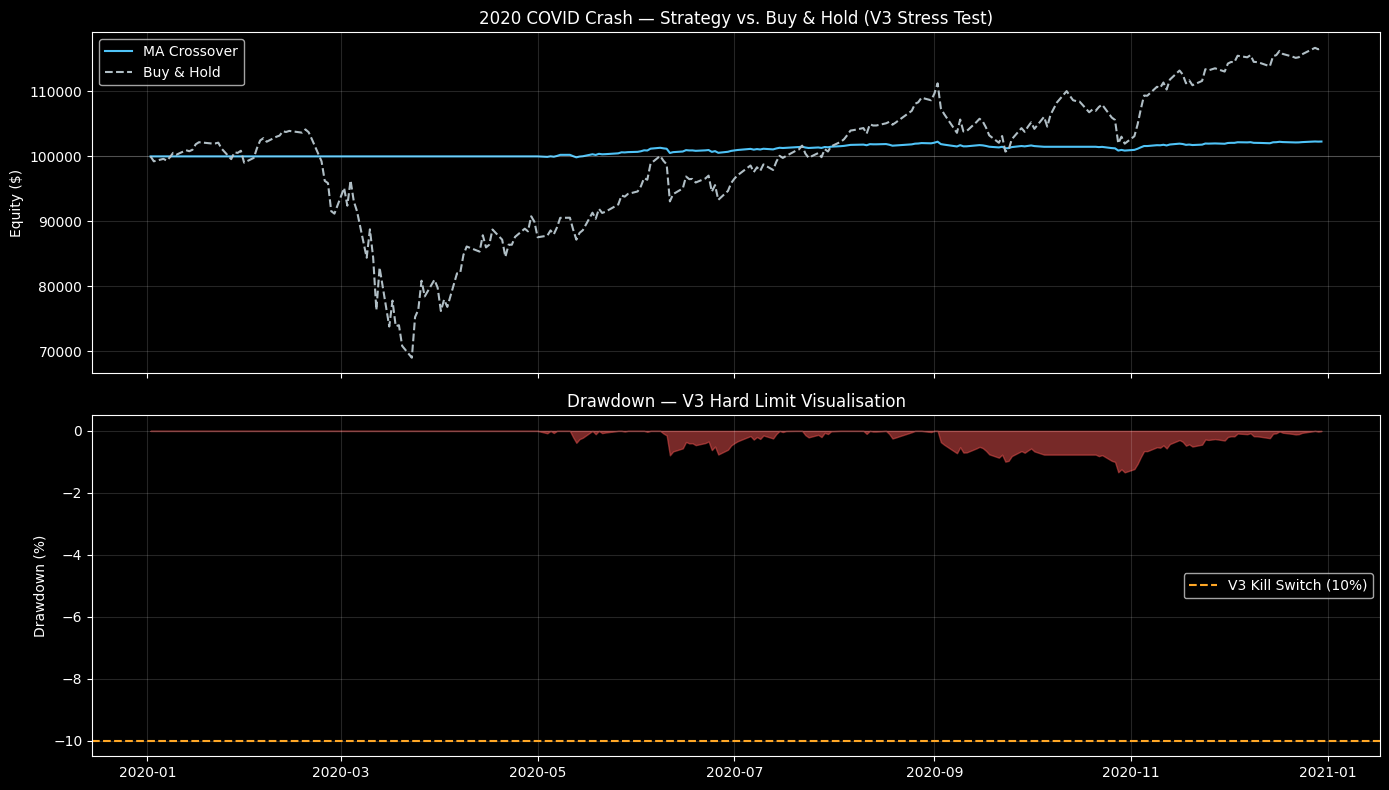


2020 Crash Results:
  Total Return  : +2.29%
  Max Drawdown  : -1.34%
  Kill Switch   : ✅ Not triggered
  Safety Events : 1
    → 2020-08-18 00:00:00 — SPY: PROFIT TAKE at 313.52


In [6]:
# Replicate the Final Milestone scenario from §9-Q4:
# "The Agent navigates a simulated 2020-style crash without hitting the
#  hard kill-switch, preserving capital through autonomous decision-making."
crash_start = datetime(2020, 1, 1)
crash_end = datetime(2020, 12, 31)

crash_data = yf.download(
    TICKER,
    start=crash_start,
    end=crash_end,
    interval="1d",
    progress=False,
    auto_adjust=True,
    multi_level_index=False,
)
crash_data.index = pd.to_datetime(crash_data.index)
crash_signals = ma_crossover_strategy(crash_data)

cfg_crash = BacktestConfig(initial_capital=100_000.0)
bt_crash = EventDrivenBacktester(cfg_crash)

for dt, row in crash_data.iterrows():
    price = float(row["Close"])
    signal = int(crash_signals.loc[dt])
    bt_crash.tick(TICKER, price, dt)
    if signal == 1 and TICKER not in bt_crash.positions:
        bt_crash.enter(TICKER, price, direction=1, dt=dt)
    elif signal != 1 and TICKER in bt_crash.positions:
        bt_crash.exit(TICKER, price, dt=dt, reason="signal")

if TICKER in bt_crash.positions:
    bt_crash.exit(
        TICKER,
        float(crash_data["Close"].iloc[-1]),
        dt=crash_data.index[-1],
        reason="end",
    )

crash_res = bt_crash.results()
crash_eq = pd.Series(bt_crash.equity_curve, index=bt_crash.timestamps)
bh_crash = (crash_data["Close"] / crash_data["Close"].iloc[0]) * 100_000.0

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(
    crash_eq.index, crash_eq, color=COLORS["primary"], label="MA Crossover"
)
axes[0].plot(
    bh_crash.index,
    bh_crash,
    color=COLORS["neutral"],
    linestyle="--",
    label="Buy & Hold",
)
axes[0].axhline(100_000, color="white", alpha=0.2, linewidth=0.8)
axes[0].set_title(
    "2020 COVID Crash — Strategy vs. Buy & Hold (V3 Stress Test)"
)
axes[0].set_ylabel("Equity ($)")
axes[0].legend()
axes[0].grid(alpha=0.15)

crash_dd = (crash_eq - crash_eq.cummax()) / crash_eq.cummax() * 100
axes[1].fill_between(
    crash_dd.index, crash_dd, 0, color=COLORS["danger"], alpha=0.5
)
axes[1].axhline(
    -MAX_DRAWDOWN_LIMIT * 100,
    color=COLORS["warning"],
    linestyle="--",
    linewidth=1.5,
    label=f"V3 Kill Switch ({MAX_DRAWDOWN_LIMIT:.0%})",
)
axes[1].set_title("Drawdown — V3 Hard Limit Visualisation")
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend()
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.savefig("04/04_crash_stress_test.png", dpi=150, bbox_inches="tight")
plt.show()

kill_switch_triggered = crash_res.get("max_drawdown", 0) < -MAX_DRAWDOWN_LIMIT
print("\n2020 Crash Results:")
print(f"  Total Return  : {crash_res.get('total_return', 0):+.2%}")
print(f"  Max Drawdown  : {crash_res.get('max_drawdown', 0):+.2%}")
print(
    "  Kill Switch   : "
    f"{'⚠️  WOULD TRIGGER' if kill_switch_triggered else '✅ Not triggered'}"
)
print(f"  Safety Events : {len(bt_crash._safety_events)}")
for ev in bt_crash._safety_events[:10]:
    print(f"    → {ev}")

## 6. Monte Carlo Return Distribution

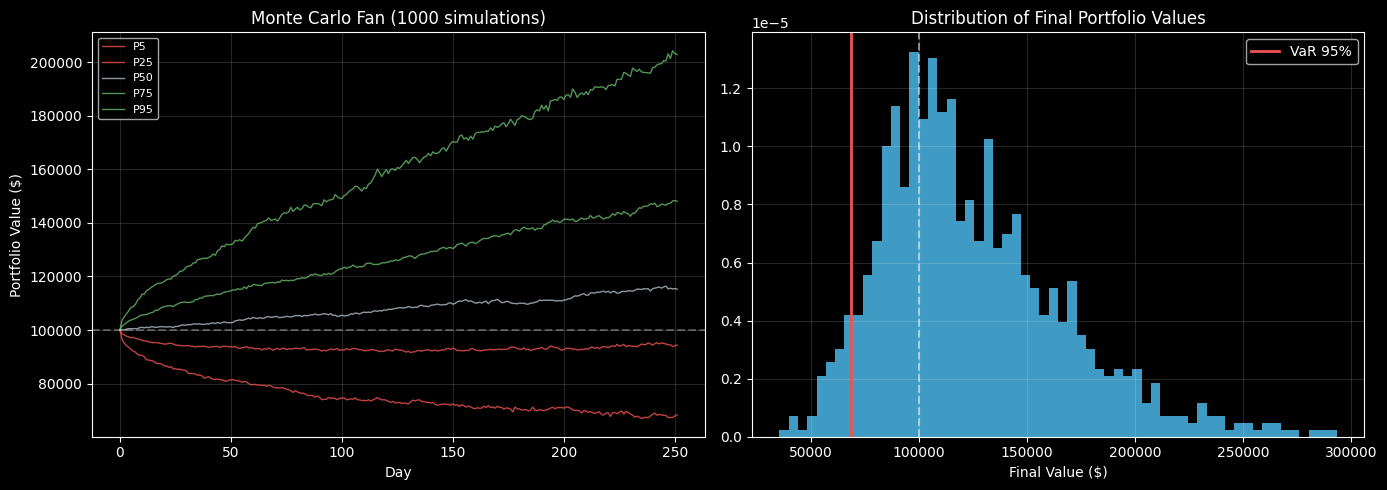


Monte Carlo VaR (95%): $68,374  (-31.63% vs starting capital)


In [7]:
# Monte Carlo simulation — base for Warp 1 (Volatility Scaling) in Phase B.
N_SIMS = 1000
N_DAYS = 252
daily_ret = crash_data["Close"].pct_change().dropna()
mu = daily_ret.mean()
sigma = daily_ret.std()

mc_paths = np.zeros((N_SIMS, N_DAYS))
mc_paths[:, 0] = 100_000.0
for t in range(1, N_DAYS):
    shocks = np.random.normal(mu, sigma, N_SIMS)
    mc_paths[:, t] = mc_paths[:, t - 1] * (1 + shocks)

final_values = mc_paths[:, -1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MC path fan chart
percentiles = [5, 25, 50, 75, 95]
for p in percentiles:
    path_p = np.percentile(mc_paths, p, axis=0)
    color = (
        COLORS["danger"]
        if p <= 25
        else (COLORS["success"] if p >= 75 else COLORS["neutral"])
    )
    axes[0].plot(path_p, color=color, linewidth=1.0, label=f"P{p}", alpha=0.8)
axes[0].axhline(100_000, color="white", linestyle="--", alpha=0.3)
axes[0].set_title(f"Monte Carlo Fan ({N_SIMS} simulations)")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.15)

# Distribution of final values
axes[1].hist(
    final_values, bins=60, color=COLORS["primary"], alpha=0.8, density=True
)
axes[1].axvline(
    np.percentile(final_values, 5),
    color=COLORS["danger"],
    linewidth=2,
    label="VaR 95%",
)
axes[1].axvline(100_000, color="white", linestyle="--", alpha=0.5)
axes[1].set_title("Distribution of Final Portfolio Values")
axes[1].set_xlabel("Final Value ($)")
axes[1].legend()
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.savefig("04/04_monte_carlo.png", dpi=150, bbox_inches="tight")
plt.show()

var_95 = np.percentile(final_values, 5)
print(
    f"\nMonte Carlo VaR (95%): ${var_95:,.0f}  "
    f"({(var_95 / 100_000 - 1):+.2%} vs starting capital)"
)